In [ ]:
Machine Learning
Dataset: Iris
Reason: Classic, lightweight dataset for classification, clustering, and visualization
url: https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.

In [2]:
# Install libraries and dependencies
!pip -q install pyspark tensorflow scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import beta

print ("libraries ready")

libraries ready


In [3]:
# Visualizations set up
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("set up complete")

set up complete


In [4]:
# Load dataset

iris_bunch = load_iris()
X = pd.DataFrame(iris_bunch.data, columns=iris_bunch.feature_names)
y = pd.Series(iris_bunch.target, name="species")

df = pd.concat([X, y], axis=1)
df["species_name"] = df["species"].map(dict(enumerate(iris_bunch.target_names)))

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [5]:
# Basic statistical analysis
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["species_name"].value_counts())



Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing values:
sepal length (cm)    0
sepal width

/tmp/ipykernel_879/2308094812.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species_name", y="petal length (cm)", data=df, ax=axes[0, 1], palette="Set2")


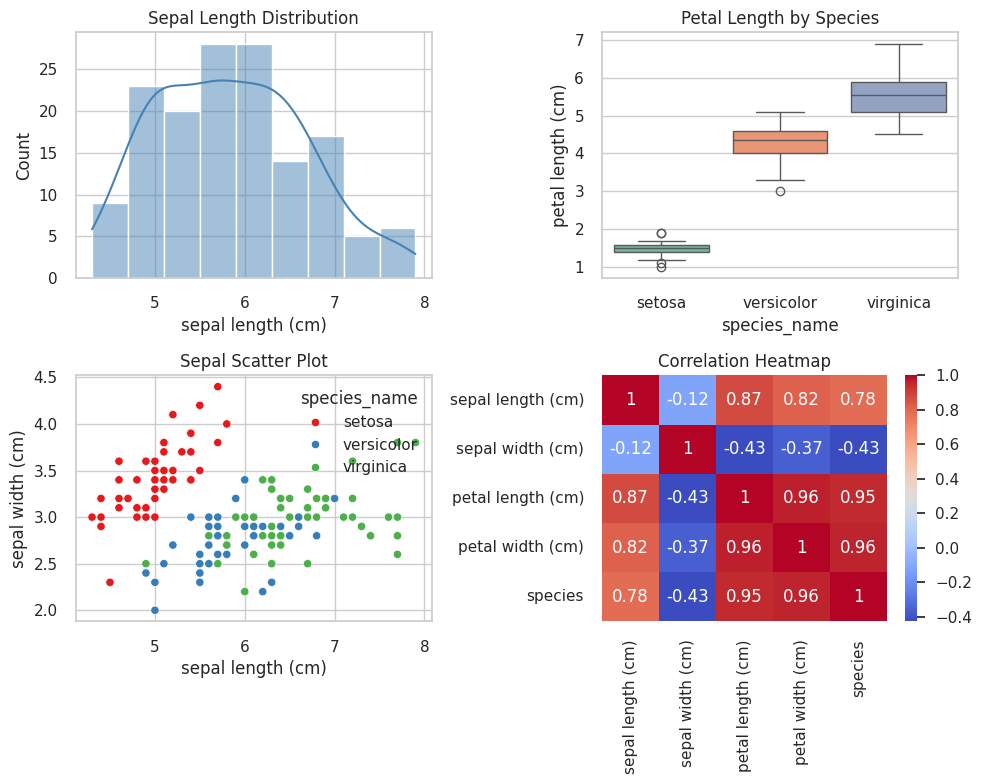

<Figure size 800x600 with 0 Axes>

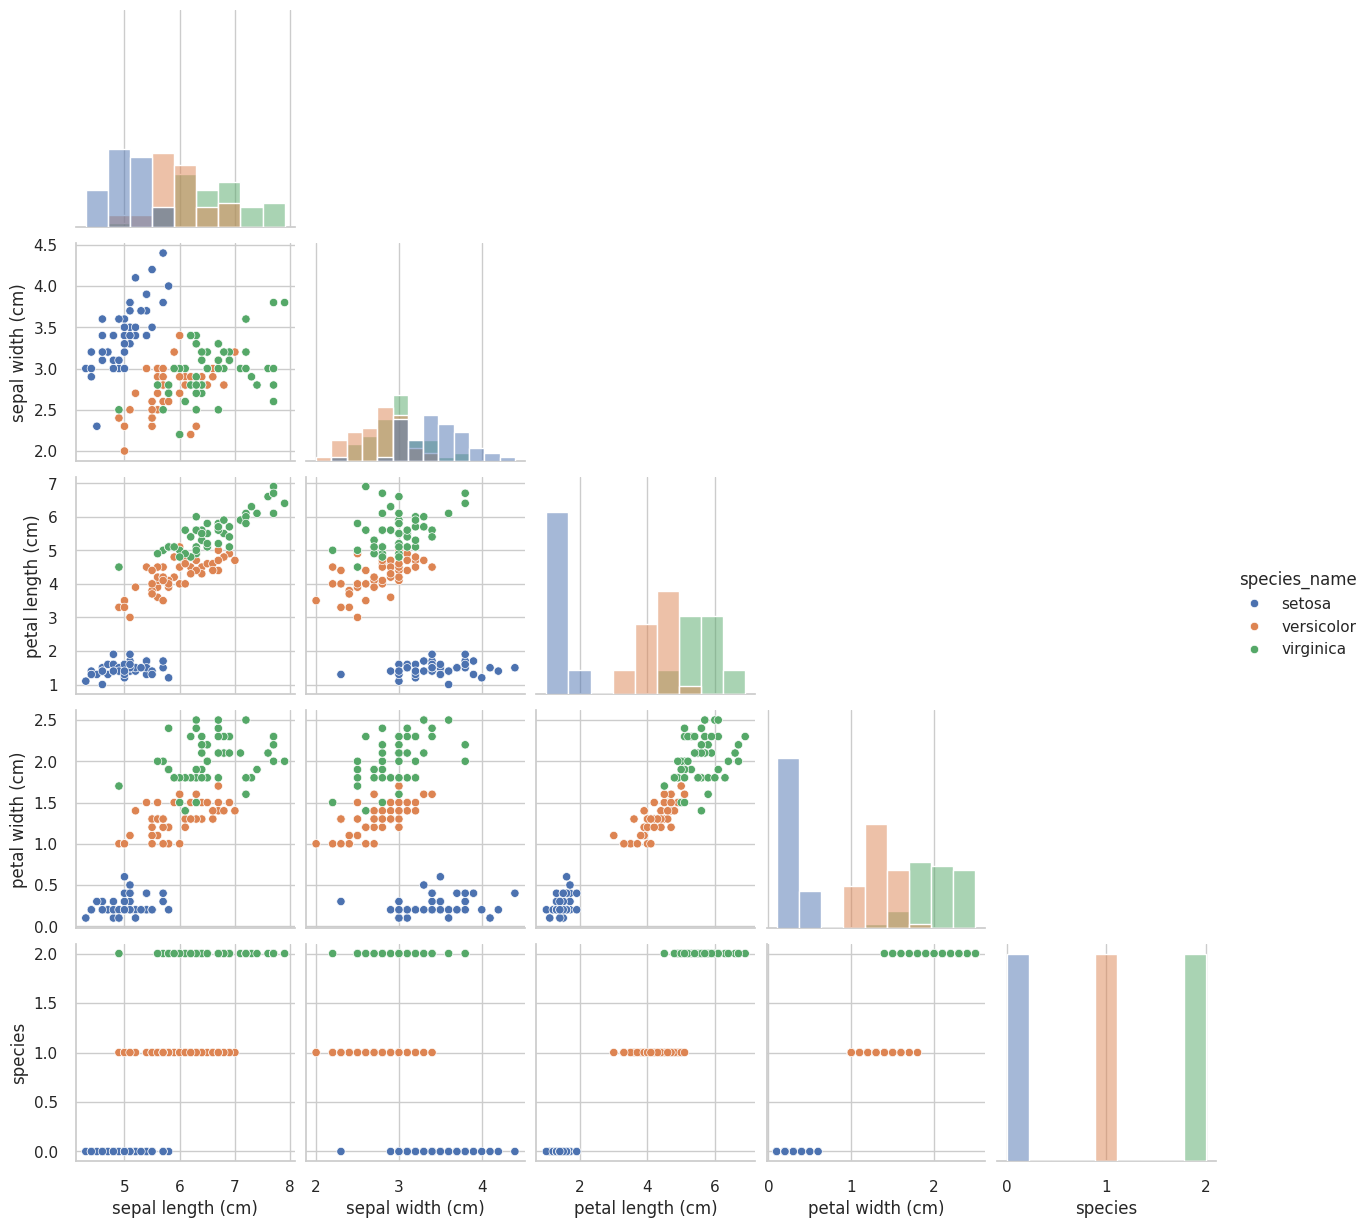

In [10]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df["sepal length (cm)"], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Sepal Length Distribution")

sns.boxplot(x="species_name", y="petal length (cm)", data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Petal Length by Species")

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species_name",
    ax=axes[1, 0],
    palette="Set1"
)
axes[1, 0].set_title("Sepal Scatter Plot")

sns.heatmap(df.drop(columns=["species_name"]).corr(), annot=True, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.pairplot(df, hue="species_name", corner=True, diag_kind="hist")
plt.show()




Logistic Regression
Accuracy: 0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Decision Tree
Accuracy: 0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Random Forest
Accuracy: 0.9
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
    

/tmp/ipykernel_879/2938832747.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")


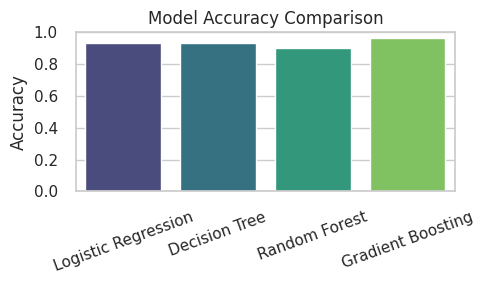

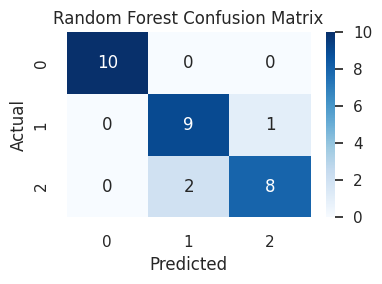

In [11]:
# Supervised Learning - Classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)

tree = DecisionTreeClassifier(random_state=42, max_depth=4)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

def show_metrics(name, y_true, pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, pred))
    print(confusion_matrix(y_true, pred))
    print(classification_report(y_true, pred, target_names=iris_bunch.target_names))

show_metrics("Logistic Regression", y_test, pred_logit)
show_metrics("Decision Tree", y_test, pred_tree)
show_metrics("Random Forest", y_test, pred_rf)
show_metrics("Gradient Boosting", y_test, pred_gb)

accs = {
    "Logistic Regression": accuracy_score(y_test, pred_logit),
    "Decision Tree": accuracy_score(y_test, pred_tree),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
}

plt.figure(figsize=(5, 3))
sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Regression section (illustrative):
MSE: 0.13001626031382674
Sample predictions: [4.12771597 1.882002   7.02565911 4.43211007 4.92719101]


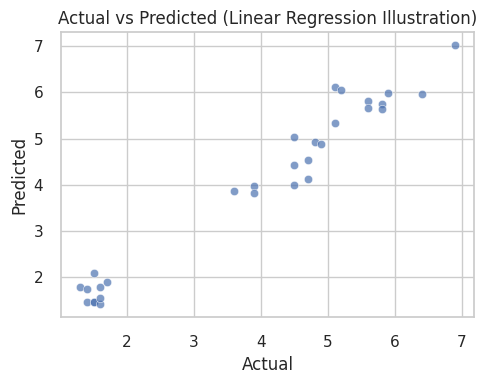

In [12]:
# Regression section
# This dataset is classification-first; regression is illustrative.
y_reg = X["petal length (cm)"]
X_reg = X.drop(columns=["petal length (cm)"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg.fit(X_train_r, y_train_r)
reg_pred = reg.predict(X_test_r)

print("\nRegression section (illustrative):")
print("MSE:", mean_squared_error(y_test_r, reg_pred))
print("Sample predictions:", reg_pred[:5])

plt.figure(figsize=(5, 4))
sns.scatterplot(x=y_test_r, y=reg_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression Illustration)")
plt.tight_layout()
plt.show()

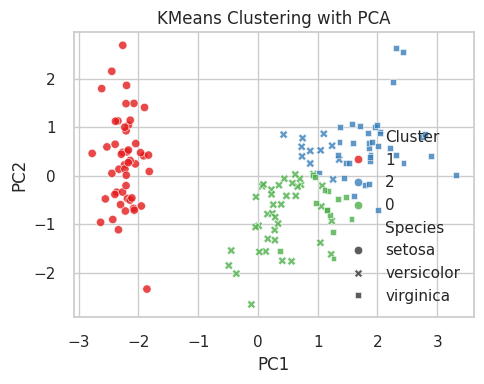

In [19]:
# 7) Unsupervised Learning - Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str),
    "Species": df["species_name"].values
})

plt.figure(figsize=(5, 4))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", style="Species", palette="Set1", alpha=0.8)
plt.title("KMeans Clustering with PCA")
plt.tight_layout()
plt.show()


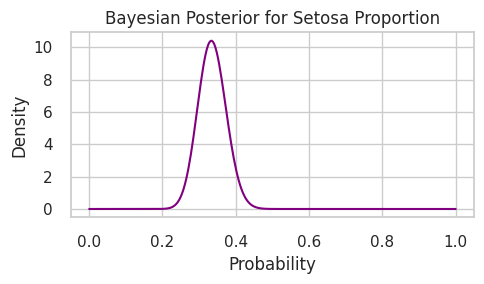


Posterior mean: 0.3355263157894737


In [15]:
# 9) Bayesian modeling - Simple Bayesian estimate for class proportion of setosa.
setosa_count = int((y == 0).sum())
non_setosa_count = int((y != 0).sum())
post_a = 1 + setosa_count
post_b = 1 + non_setosa_count

x_vals = np.linspace(0, 1, 300)
posterior = beta.pdf(x_vals, post_a, post_b)

plt.figure(figsize=(5, 3))
plt.plot(x_vals, posterior, color="purple")
plt.title("Bayesian Posterior for Setosa Proportion")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("\nPosterior mean:", post_a / (post_a + post_b))



TensorFlow test accuracy: 0.800000011920929


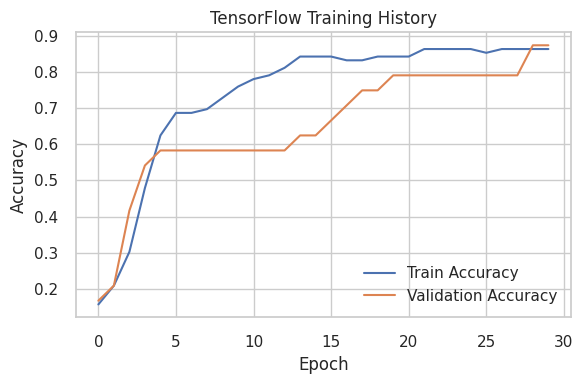

In [17]:
# TensorFlow model
y_cat = tf.keras.utils.to_categorical(y, num_classes=3)
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y
)

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

tf_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history = tf_model.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=0
)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print("\nTensorFlow test accuracy:", tf_acc)

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
# PySpark

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier as SparkDecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("IrisDataset").getOrCreate()

spark_df = spark.createDataFrame(df.drop(columns=["species_name"]))

print("\nPySpark shape:", (spark_df.count(), len(spark_df.columns)))

feature_cols = list(iris_bunch.feature_names)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_sp = SparkStandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

train_sp, test_sp = spark_df.randomSplit([0.8, 0.2], seed=42)

spark_lr = SparkLogisticRegression(featuresCol="features", labelCol="species", maxIter=50, family="multinomial")
spark_dt = SparkDecisionTreeClassifier(featuresCol="features", labelCol="species")
spark_rf = SparkRandomForestClassifier(featuresCol="features", labelCol="species", numTrees=100)

# GBT skipped for multiclass - not supported in Spark MLlib
# For multiclass, we can just not train GBT or use a different approach

pipeline_lr = SparkPipeline(stages=[assembler, scaler_sp, spark_lr])
pipeline_dt = SparkPipeline(stages=[assembler, scaler_sp, spark_dt])
pipeline_rf = SparkPipeline(stages=[assembler, scaler_sp, spark_rf])

m_lr = pipeline_lr.fit(train_sp)
m_dt = pipeline_dt.fit(train_sp)
m_rf = pipeline_rf.fit(train_sp)

p_lr = m_lr.transform(test_sp)
p_dt = m_dt.transform(test_sp)
p_rf = m_rf.transform(test_sp)

evaluator = MulticlassClassificationEvaluator(labelCol="species", predictionCol="prediction", metricName="accuracy")

print("\nPySpark accuracies:")
print("Logistic Regression:", evaluator.evaluate(p_lr))
print("Decision Tree:", evaluator.evaluate(p_dt))
print("Random Forest:", evaluator.evaluate(p_rf))

# Note: GBTClassifier is not included because it only supports binary classification in Spark MLlib

spark.stop()


PySpark shape: (150, 5)

PySpark accuracies:
Logistic Regression: 1.0
Decision Tree: 0.96875
Random Forest: 0.96875


In [21]:
# End
print("\nCompleted Iris dataset workflow.")


Completed Iris dataset workflow.
